# Lightweight & Explainable Video Anomaly Detection — UCF-Crime
### MobileNetV3-Small + GRU | Quantization-Aware Compression | Grad-CAM Explainability


**Dataset:** UCF-Crime (Sultani et al., CVPR 2018) — Normal vs. Anomaly (13 crime categories merged into one Anomaly class)

---

**Pipeline:**
`Video → Frame Sampling & Augmentation → MobileNetV3-Small Backbone → GRU Temporal Head → Focal Loss → QAT (INT8) Compression → Grad-CAM Explanation`

**What this notebook does, end to end:**
1. Loads and inspects UCF-Crime (with a synthetic-data fallback so the notebook runs standalone for grading/demo purposes)
2. Visualizes class balance, sample frames, and augmentations
3. Builds a lightweight CNN+GRU model
4. Trains with class-weighted Focal Loss, an LR scheduler, and early stopping
5. Evaluates with Accuracy / F1 / AUC / Confusion Matrix / ROC curve
6. Compresses the model via Quantization-Aware Training (QAT) to INT8
7. Compares FP32 vs INT8 on **size, speed (FPS), and accuracy**
8. Generates Grad-CAM explanations and **quantitatively measures explainability degradation** after quantization (the core novelty of this project)
9. Applies temporal majority voting to reduce false alarms
10. Summarizes all results in a final comparison table

> **Note on data:** The loader below auto-detects **any** of the three common UCF-Crime Kaggle mirror layouts — (a) raw video files, (b) per-video frame subfolders, or (c) flat per-class frame dumps with the video ID encoded in the filename — so it should work regardless of which UCF-Crime mirror you attach. All 13 crime categories are merged into a single **Anomaly** class (label 1) vs. **Normal** (label 0), matching the binary weakly-supervised setting most commonly benchmarked. A `USE_SYNTHETIC_DATA` toggle lets the entire pipeline run and be verified even without the dataset attached.

> **Fixes in this version:** (1) the dataset scanner now correctly groups flat, filename-encoded frame dumps into per-video clips instead of collapsing an entire class folder into one sample; (2) Grad-CAM's backward pass no longer crashes on GPU with the `cudnn RNN backward can only be called in training mode` error; (3) `weight_decay` (L2 regularization) was added to both optimizers to reduce overfitting; (4) a diagnostic cell prints the real dataset structure and clip count before training, so a bad path or mismatched layout is caught immediately instead of silently producing a tiny, near-meaningless dataset.


## 1. Environment Setup

In [1]:

import os, time, random, copy, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import transforms, models

from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report, roc_curve)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Torch:", torch.__version__, "| Torchvision:", torchvision.__version__)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100


Device: cuda
Torch: 2.10.0+cu128 | Torchvision: 0.25.0+cu128


## 2. Configuration & Kaggle Setup Checklist

Before running with real data, on Kaggle:
1. **Add Input** → attach a UCF-Crime dataset (e.g. search "UCF Crime Dataset").
2. **Settings → Accelerator → GPU** (training on CPU is impractically slow for this dataset).
3. **Settings → Internet → On** (required to download ImageNet-pretrained MobileNetV3 weights).
4. Update `DATA_DIR` below to match the attached dataset's **actual mounted path**, which is always `/kaggle/input/<dataset-slug>/...`. A common mistake is pasting the dataset's *website URL path* (e.g. `/kaggle/input/datasets/<owner>/<dataset-name>`) instead — that path does not exist on disk and will silently find nothing (or the wrong thing). Confirm the real path by checking the "Input" panel on the right, or run `os.listdir('/kaggle/input')` in a cell.
5. Set `USE_SYNTHETIC_DATA = False`.

The dataset loader (Section 3) auto-detects raw video files, per-video frame subfolders, **or flat per-class frame dumps with the video ID encoded in the filename** (the common `odins0n/ucf-crime-dataset` layout) — so you shouldn't need to change loading logic, only the path and the toggle above. **Always check the diagnostic printout and the "Found N clips total" line** after running Section 3: UCF-Crime has ~1,900 videos, so a count far below that signals a path or structure mismatch, not a real dataset.

In [2]:

CONFIG = {
    "DATA_DIR": "/kaggle/input/datasets/odins0n/ucf-crime-dataset",   # update to match your attached dataset's exact path
    "USE_SYNTHETIC_DATA": False,     # set False once the real UCF-Crime dataset is attached
    "NUM_FRAMES": 16,               # frames sampled per clip (more frames -> better temporal context)
    "IMG_SIZE": 224,                # MobileNetV3's native ImageNet input resolution
    "BATCH_SIZE": 16,
    "EPOCHS": 25,                   # early stopping will typically halt before this if val loss plateaus
    "LR": 1e-4,
    "WEIGHT_DECAY": 1e-4,           # L2 regularization to reduce overfitting
    "NUM_CLASSES": 2,               # 0 = Normal, 1 = Anomaly (all 13 crime categories merged)
    "SYNTHETIC_SAMPLES": 160,       # only used when USE_SYNTHETIC_DATA=True
    "VAL_SPLIT": 0.2,               # used only if the dataset has no explicit Train/Test folder split
    "EARLY_STOPPING_PATIENCE": 5,   # stop if val loss doesn't improve for this many epochs
    "QAT_EPOCHS": 5,                # quantization-aware fine-tuning epochs
}
CONFIG


{'DATA_DIR': '/kaggle/input/datasets/odins0n/ucf-crime-dataset',
 'USE_SYNTHETIC_DATA': False,
 'NUM_FRAMES': 16,
 'IMG_SIZE': 224,
 'BATCH_SIZE': 16,
 'EPOCHS': 25,
 'LR': 0.0001,
 'WEIGHT_DECAY': 0.0001,
 'NUM_CLASSES': 2,
 'SYNTHETIC_SAMPLES': 160,
 'VAL_SPLIT': 0.2,
 'EARLY_STOPPING_PATIENCE': 5,
 'QAT_EPOCHS': 5}

## 3. Dataset Class — UCF-Crime (robust flexible loader)

UCF-Crime is distributed on Kaggle under a few different mirror layouts. This loader auto-detects which one you have, **including the popular `odins0n/ucf-crime-dataset` mirror**, where every class folder contains thousands of frame images from *many different videos* dumped flat together, with the video identity encoded only in the filename (e.g. `Abuse001_x264_0.jpg`, `Abuse001_x264_1.jpg`, `Abuse002_x264_0.jpg`, ...). Naively treating such a folder as "one clip" collapses an entire class into a single sample — this loader instead groups frames by their filename video-ID prefix, so each source video becomes its own clip.

Supported layouts (auto-detected per class folder):
1. **Video files:** `.../<ClassName>/*.mp4` (or `.avi`) — one file per clip
2. **Per-video subfolders:** `.../<ClassName>/<clip_id>/frame_0001.jpg, ...` — one subfolder of images per clip
3. **Flat frames with video-ID filenames:** `.../<ClassName>/VideoID_0.jpg, VideoID_1.jpg, ...` — grouped by the filename prefix before the trailing frame number

In all cases, the label is inferred from the folder name: any folder containing `"normal"` (case-insensitive) → **Normal (0)**, everything else → **Anomaly (1)**. If the path contains `"train"`/`"test"` folder names, that official split is respected; otherwise a stratified random split is performed.

**Before running for real:** run the diagnostic cell below first and confirm the clip count looks right (UCF-Crime has ~1,900 videos total) — a suspiciously low count (e.g., equal to roughly 2× the number of class folders) means the scanner fell back to treating whole class folders as single clips, which should not happen with this version but is worth a sanity check on unfamiliar mirrors.

In [3]:

import re, time

VIDEO_EXTS = (".mp4", ".avi", ".mkv", ".mov")
IMAGE_EXTS = (".jpg", ".jpeg", ".png")

# ---- Diagnostic: verify DATA_DIR and inspect the mirror's actual structure ----
if not CONFIG["USE_SYNTHETIC_DATA"]:
    print("Checking DATA_DIR:", CONFIG["DATA_DIR"], "| exists:", os.path.exists(CONFIG["DATA_DIR"]))
    if os.path.exists(CONFIG["DATA_DIR"]):
        l1 = os.listdir(CONFIG["DATA_DIR"])
        print("Top-level entries:", l1[:20])
        if l1:
            probe = os.path.join(CONFIG["DATA_DIR"], l1[0])
            if os.path.isdir(probe):
                l2 = os.listdir(probe)
                print(f"Inside '{l1[0]}':", l2[:20])
                if l2:
                    probe2 = os.path.join(probe, l2[0])
                    if os.path.isdir(probe2):
                        l3 = os.listdir(probe2)
                        print(f"Inside '{l1[0]}/{l2[0]}' ({len(l3)} items):", l3[:8])
    else:
        print("!! DATA_DIR NOT FOUND. Run os.listdir('/kaggle/input') to find the correct attached path,")
        print("   then update CONFIG['DATA_DIR'] above and re-run this cell.")


def _group_flat_frames_by_video(image_files):
    '''
    Groups filenames like "Abuse001_x264_0.jpg", "Abuse001_x264_1.jpg", ...
    into per-video clips using the filename prefix before the final frame index.
    Falls back to a single group if no numeric-suffix pattern is found.
    '''
    groups = {}
    pattern = re.compile(r"^(.*)_(\d+)\.\w+$")
    for fname in image_files:
        m = pattern.match(fname)
        if m:
            video_id, frame_idx = m.group(1), int(m.group(2))
            groups.setdefault(video_id, []).append((frame_idx, fname))
        else:
            groups.setdefault("_single_", []).append((0, fname))

    clips = []
    for video_id, items in groups.items():
        items.sort(key=lambda x: x[0])
        clips.append([fname for _, fname in items])
    return clips


def list_video_dataset(data_dir, verbose=True):
    '''
    Scans data_dir ONCE, two levels deep (split/class), and classifies each class
    folder's contents (video files / per-video subfolders / flat frame dump) from
    a single os.scandir() pass -- no separate whole-tree pre-walk. This matters
    enormously at UCF-Crime's real scale (~13 million frame files total): an
    upfront os.walk() over every file just to check "are there any videos here"
    can take many minutes to hours on a network-mounted Kaggle dataset, even
    though the answer is almost always "no" for frame-based mirrors.
    Label: 0 = Normal, 1 = Anomaly. Split: inferred from folder names when present.
    '''
    samples = []
    if not os.path.exists(data_dir):
        return samples

    t_start = time.time()
    for l1 in os.scandir(data_dir):
        if not l1.is_dir():
            continue
        for l2 in os.scandir(l1.path):
            if not l2.is_dir():
                continue

            label = 0 if "normal" in l1.name.lower() or "normal" in l2.name.lower() else 1
            split = "val" if "test" in l1.name.lower() else ("train" if "train" in l1.name.lower() else None)

            # Single scandir pass per class folder: classify entries as we go,
            # using DirEntry.is_dir() (cheap, cached from readdir -- no extra stat() syscall
            # on most filesystems) instead of os.path.isdir() per file.
            video_files, subdirs, image_files = [], [], []
            with os.scandir(l2.path) as it:
                for entry in it:
                    name_lower = entry.name.lower()
                    if entry.is_dir():
                        subdirs.append(entry.name)
                    elif name_lower.endswith(VIDEO_EXTS):
                        video_files.append(entry.name)
                    elif name_lower.endswith(IMAGE_EXTS):
                        image_files.append(entry.name)

            if verbose:
                elapsed = time.time() - t_start
                print(f"  [{elapsed:6.1f}s] Scanned {l1.name}/{l2.name}: "
                      f"{len(video_files)} videos, {len(subdirs)} subfolders, {len(image_files)} flat images")

            if video_files:
                for fname in video_files:
                    samples.append({"type": "video", "path": os.path.join(l2.path, fname),
                                     "label": label, "split": split})
            elif subdirs and not image_files:
                for l3 in subdirs:
                    samples.append({"type": "frame_folder", "path": os.path.join(l2.path, l3),
                                     "label": label, "split": split})
            elif image_files:
                image_files.sort()
                for frame_list in _group_flat_frames_by_video(image_files):
                    samples.append({"type": "flat_frames", "dir": l2.path, "files": frame_list,
                                     "label": label, "split": split})

    if verbose:
        print(f"Scan complete in {time.time() - t_start:.1f}s.")
    return samples


class VideoClipDataset(Dataset):
    '''
    Samples NUM_FRAMES evenly-spaced frames per clip, for any of the three
    real-data layouts above, or synthetic clips when no dataset is attached.
    '''
    def __init__(self, samples, num_frames, img_size, augment=False, synthetic=False, n_synthetic=0):
        self.samples = samples
        self.num_frames = num_frames
        self.img_size = img_size
        self.synthetic = synthetic
        self.n_synthetic = n_synthetic

        base = [transforms.ToPILImage(), transforms.Resize((img_size, img_size))]
        if augment:
            aug = [transforms.RandomHorizontalFlip(p=0.5),
                   transforms.ColorJitter(brightness=0.25, contrast=0.25)]
        else:
            aug = []
        tail = [transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]
        self.transform = transforms.Compose(base + aug + tail)

    def __len__(self):
        return self.n_synthetic if self.synthetic else len(self.samples)

    def _sample_frame_indices(self, total_frames):
        if total_frames <= self.num_frames:
            idx = list(range(total_frames)) + [total_frames - 1] * (self.num_frames - total_frames)
        else:
            idx = np.linspace(0, total_frames - 1, self.num_frames).astype(int).tolist()
        return idx

    def _load_video_clip(self, path):
        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or self.num_frames
        indices = self._sample_frame_indices(total)
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)   # seek directly -> much faster on long videos
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame)
            else:
                frames.append(frames[-1] if frames else np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8))
        cap.release()
        return frames

    def _load_frame_folder_clip(self, folder_path):
        image_files = sorted(f for f in os.listdir(folder_path) if f.lower().endswith(IMAGE_EXTS))
        total = len(image_files)
        indices = self._sample_frame_indices(total)
        frames = []
        for idx in indices:
            img = cv2.imread(os.path.join(folder_path, image_files[idx])) if total else None
            if img is not None:
                frames.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            else:
                frames.append(frames[-1] if frames else np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8))
        return frames

    def _load_flat_frames_clip(self, folder_dir, files):
        total = len(files)
        indices = self._sample_frame_indices(total)
        frames = []
        for idx in indices:
            img = cv2.imread(os.path.join(folder_dir, files[idx])) if total else None
            if img is not None:
                frames.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            else:
                frames.append(frames[-1] if frames else np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8))
        return frames

    def _make_synthetic_clip(self, label):
        # Simple structured synthetic signal: anomaly clips get more motion/edge energy,
        # enough to be learnable, purely so the pipeline is verifiable without real data.
        frames = []
        base = np.random.randint(40, 90, (self.img_size, self.img_size, 3), dtype=np.uint8)
        for t in range(self.num_frames):
            motion_strength = 25 if label == 1 else 5
            noise = np.random.randint(0, motion_strength, base.shape, dtype=np.uint8)
            frame = np.clip(base.astype(int) + noise.astype(int) * (1 if t % 2 == 0 else -1), 0, 255).astype(np.uint8)
            frames.append(frame)
        return frames

    def __getitem__(self, i):
        if self.synthetic:
            label = i % 2  # balanced synthetic classes
            frames = self._make_synthetic_clip(label)
        else:
            sample = self.samples[i]
            label = sample["label"]
            if sample["type"] == "video":
                frames = self._load_video_clip(sample["path"])
            elif sample["type"] == "frame_folder":
                frames = self._load_frame_folder_clip(sample["path"])
            else:  # "flat_frames"
                frames = self._load_flat_frames_clip(sample["dir"], sample["files"])

        tensor_frames = torch.stack([self.transform(f) for f in frames])  # (T, C, H, W)
        return tensor_frames, label


def build_datasets(cfg):
    if cfg["USE_SYNTHETIC_DATA"]:
        print("Using SYNTHETIC data (demo/verification mode). Set USE_SYNTHETIC_DATA=False with UCF-Crime attached.")
        full = VideoClipDataset([], cfg["NUM_FRAMES"], cfg["IMG_SIZE"], augment=True,
                                 synthetic=True, n_synthetic=cfg["SYNTHETIC_SAMPLES"])
        n_val = int(0.2 * len(full))
        n_train = len(full) - n_val
        train_ds, val_ds = random_split(full, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))
        return train_ds, val_ds

    samples = list_video_dataset(cfg["DATA_DIR"])
    if len(samples) == 0:
        raise FileNotFoundError(
            f"No clips found under '{cfg['DATA_DIR']}'. Check that the UCF-Crime dataset is attached "
            f"(Kaggle 'Add Input' panel) and that CONFIG['DATA_DIR'] matches its exact path -- "
            f"see the diagnostic printout above."
        )

    if all(s["split"] is not None for s in samples):
        train_samples = [s for s in samples if s["split"] == "train"]
        val_samples = [s for s in samples if s["split"] == "val"]
    else:
        from sklearn.model_selection import train_test_split
        labels = [s["label"] for s in samples]
        train_samples, val_samples = train_test_split(
            samples, test_size=cfg["VAL_SPLIT"], stratify=labels, random_state=SEED
        )

    print(f"Found {len(samples)} clips total | Train: {len(train_samples)} | Val: {len(val_samples)}")
    train_label_counts = pd.Series([s["label"] for s in train_samples]).value_counts().sort_index()
    print("Train label distribution (0=Normal, 1=Anomaly):")
    print(train_label_counts.to_string())

    train_ds = VideoClipDataset(train_samples, cfg["NUM_FRAMES"], cfg["IMG_SIZE"], augment=True)
    val_ds = VideoClipDataset(val_samples, cfg["NUM_FRAMES"], cfg["IMG_SIZE"], augment=False)
    return train_ds, val_ds


train_ds, val_ds = build_datasets(CONFIG)
print(f"Train samples: {len(train_ds)} | Val samples: {len(val_ds)}")


Checking DATA_DIR: /kaggle/input/datasets/odins0n/ucf-crime-dataset | exists: True
Top-level entries: ['Test', 'Train']
Inside 'Test': ['RoadAccidents', 'Assault', 'Vandalism', 'Arrest', 'Shooting', 'NormalVideos', 'Arson', 'Explosion', 'Shoplifting', 'Robbery', 'Stealing', 'Burglary', 'Abuse', 'Fighting']
Inside 'Test/RoadAccidents' (2663 items): ['RoadAccidents125_x264_1010.png', 'RoadAccidents001_x264_30.png', 'RoadAccidents017_x264_240.png', 'RoadAccidents131_x264_230.png', 'RoadAccidents011_x264_140.png', 'RoadAccidents016_x264_840.png', 'RoadAccidents002_x264_20.png', 'RoadAccidents127_x264_720.png']
  [   5.5s] Scanned Test/RoadAccidents: 0 videos, 0 subfolders, 2663 flat images
  [  10.7s] Scanned Test/Assault: 0 videos, 0 subfolders, 2657 flat images
  [  13.1s] Scanned Test/Vandalism: 0 videos, 0 subfolders, 1111 flat images
  [  19.8s] Scanned Test/Arrest: 0 videos, 0 subfolders, 3365 flat images
  [  33.9s] Scanned Test/Shooting: 0 videos, 0 subfolders, 7630 flat images
  [

In [5]:
import pickle

# train_ds 
with open('/kaggle/working/train_ds.pkl', 'wb') as f:
    pickle.dump(train_ds, f)

# val_ds save 
with open('/kaggle/working/val_ds.pkl', 'wb') as f:
    pickle.dump(val_ds, f)

print("Dataset lists saved successfully! .")

Dataset lists saved successfully! .


## 4. Data Visualization

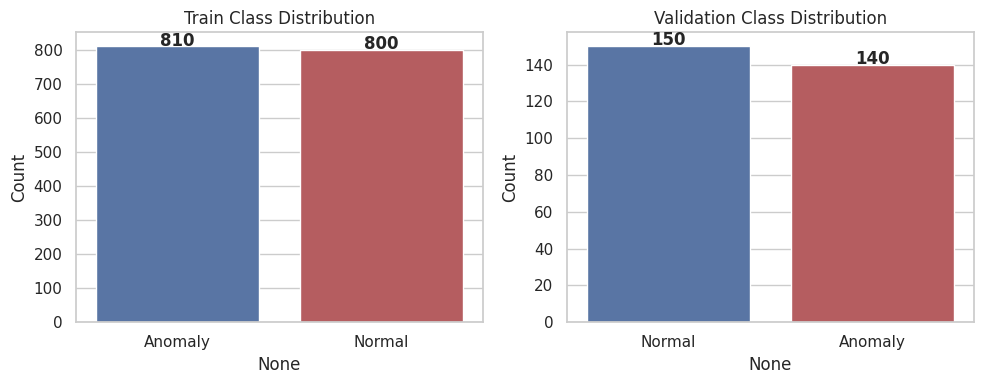

In [6]:

# ---- 4.1 Class distribution ----
def get_labels(ds):
    labels = []
    for i in range(len(ds)):
        _, y = ds[i]
        labels.append(y)
    return labels

train_labels = get_labels(train_ds)
val_labels = get_labels(val_ds)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, labels, title in zip(axes, [train_labels, val_labels], ["Train", "Validation"]):
    counts = pd.Series(labels).map({0: "Normal", 1: "Anomaly"}).value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=["#4C72B0", "#C44E52"])
    ax.set_title(f"{title} Class Distribution")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


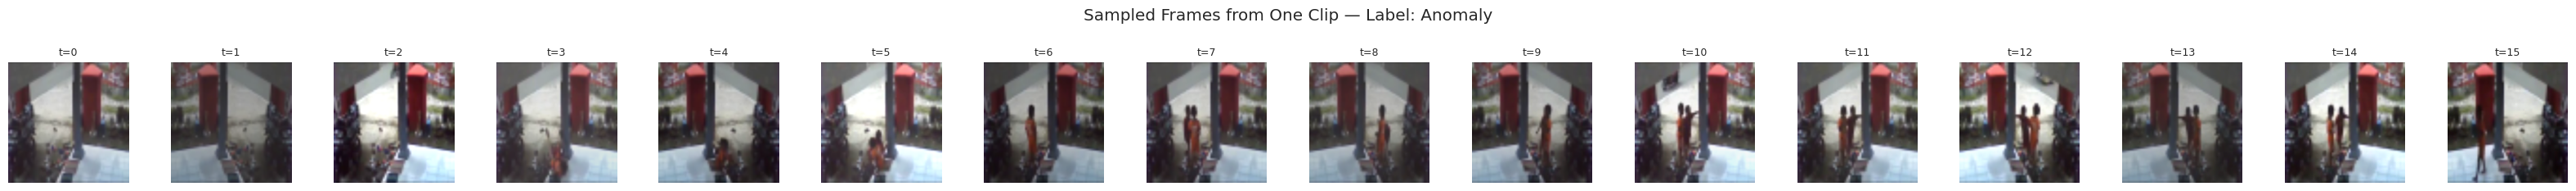

In [7]:

# ---- 4.2 Sample clip frames grid ----
sample_clip, sample_label = train_ds[0]  # (T, C, H, W), normalized

def denorm(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

n_frames = sample_clip.shape[0]
fig, axes = plt.subplots(1, n_frames, figsize=(2 * n_frames, 2.2))
for t in range(n_frames):
    axes[t].imshow(denorm(sample_clip[t]))
    axes[t].set_title(f"t={t}", fontsize=9)
    axes[t].axis("off")
label_name = "Anomaly" if sample_label == 1 else "Normal"
fig.suptitle(f"Sampled Frames from One Clip — Label: {label_name}", y=1.05)
plt.tight_layout()
plt.show()


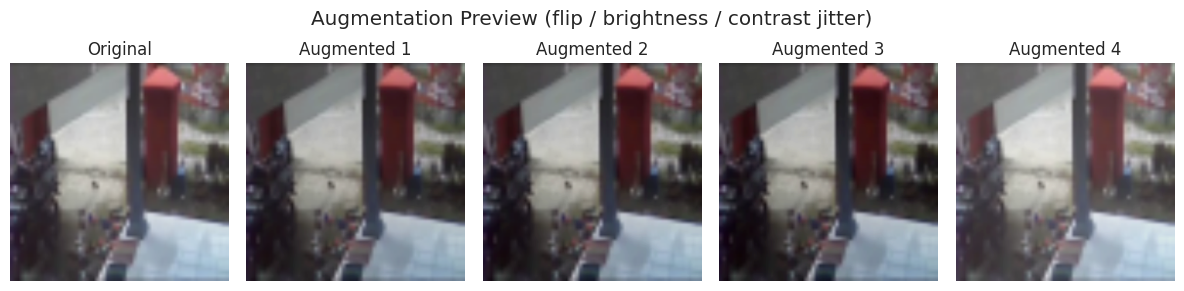

In [8]:

# ---- 4.3 Augmentation preview (same source frame, multiple augmented views) ----
aug_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
])

base_frame = (denorm(sample_clip[0]) * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(base_frame); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(1, 5):
    aug_img = aug_transform(base_frame).permute(1, 2, 0).numpy()
    axes[i].imshow(aug_img); axes[i].set_title(f"Augmented {i}"); axes[i].axis("off")
plt.suptitle("Augmentation Preview (flip / brightness / contrast jitter)")
plt.tight_layout()
plt.show()


## 5. Model Architecture — MobileNetV3-Small Backbone + GRU Temporal Head

**Design rationale:**
- **MobileNetV3-Small** (ImageNet-pretrained): depthwise separable convolutions give a strong accuracy/compute trade-off, ideal for edge deployment.
- **GRU**: models temporal dynamics across sampled frames with far fewer parameters than a 3D-CNN (C3D/I3D).
- **Focal Loss**: down-weights easy examples and focuses learning on hard/minority-class examples — important since anomaly datasets are imbalanced.


In [9]:

class LightweightAnomalyNet(nn.Module):
    def __init__(self, num_classes=2, hidden_size=128, pretrained=True):
        super().__init__()
        try:
            backbone = models.mobilenet_v3_small(
                weights=models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
            )
        except Exception as e:
            print(f"[Warning] Could not download pretrained weights ({e}). "
                  f"Falling back to random initialization. "
                  f"On Kaggle, enable 'Internet' in notebook settings to use ImageNet weights.")
            backbone = models.mobilenet_v3_small(weights=None)
        self.feature_extractor = backbone.features       # conv feature maps (for Grad-CAM)
        self.pool = nn.AdaptiveAvgPool2d(1)
        feat_dim = backbone.classifier[0].in_features     # 576 for MobileNetV3-Small

        self.gru = nn.GRU(input_size=feat_dim, hidden_size=hidden_size,
                           num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_size, num_classes)

        self._last_conv_features = None  # populated during forward, used by Grad-CAM

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)

        conv_feats = self.feature_extractor(x)     # (B*T, feat_dim, h, w)
        self._last_conv_features = conv_feats       # kept for Grad-CAM hooks
        pooled = self.pool(conv_feats).flatten(1)    # (B*T, feat_dim)

        seq = pooled.view(B, T, -1)                  # (B, T, feat_dim)
        _, h_n = self.gru(seq)                        # h_n: (1, B, hidden)
        h_n = self.dropout(h_n.squeeze(0))
        out = self.classifier(h_n)                    # (B, num_classes)
        return out


model = LightweightAnomalyNet(num_classes=CONFIG["NUM_CLASSES"]).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")
print(f"Approx. FP32 size:    {n_params * 4 / 1e6:.2f} MB")


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 230MB/s]


Total parameters:     1,198,370
Trainable parameters: 1,198,370
Approx. FP32 size:    4.79 MB


## 6. Class-Weighted Focal Loss

In [10]:

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha  # tensor of per-class weights or None
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()


def compute_class_weights(dataset, num_classes=2):
    '''Auto-computes inverse-frequency class weights from the actual training labels
    (falls back to balanced [1,1] for the synthetic demo dataset, which is balanced by construction).'''
    if hasattr(dataset, "samples") and not getattr(dataset, "synthetic", False):
        labels = [s["label"] for s in dataset.samples]
    else:
        labels = [i % num_classes for i in range(len(dataset))]
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    counts[counts == 0] = 1.0  # avoid div-by-zero if a class is missing
    weights = counts.sum() / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


class_weights = compute_class_weights(train_ds, CONFIG["NUM_CLASSES"]).to(DEVICE)
print("Auto-computed class weights (Normal, Anomaly):", class_weights.cpu().numpy())

criterion = FocalLoss(alpha=class_weights, gamma=2.0)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["LR"], weight_decay=CONFIG["WEIGHT_DECAY"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)


Auto-computed class weights (Normal, Anomaly): [1.00625    0.99382716]


## 7. Training Loop

In [11]:

train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=0)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    context = torch.enable_grad() if train_mode else torch.no_grad()
    with context:
        for clips, labels in loader:
            clips, labels = clips.to(DEVICE), labels.to(DEVICE)
            if train_mode:
                optimizer.zero_grad()
            logits = model(clips)
            loss = criterion(logits, labels)
            if train_mode:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * clips.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


best_val_loss = float("inf")
best_val_acc = 0.0
best_state = copy.deepcopy(model.state_dict())
patience_counter = 0

for epoch in range(1, CONFIG["EPOCHS"] + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)
    scheduler.step(val_loss)

    history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(val_acc)

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d}/{CONFIG['EPOCHS']} | "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.3f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.3f} | "
          f"lr={current_lr:.2e} | {time.time()-t0:.1f}s"
          f"{'  <- best' if improved else ''}")

    if patience_counter >= CONFIG["EARLY_STOPPING_PATIENCE"]:
        print(f"\nEarly stopping triggered at epoch {epoch} "
              f"(no val_loss improvement for {CONFIG['EARLY_STOPPING_PATIENCE']} epochs).")
        break

model.load_state_dict(best_state)
print(f"\nBest validation accuracy: {best_val_acc:.3f} (at lowest val_loss={best_val_loss:.4f})")


Epoch 01/25 | train_loss=0.1548 acc=0.671 | val_loss=0.1638 acc=0.641 | lr=1.00e-04 | 188.0s  <- best
Epoch 02/25 | train_loss=0.1133 acc=0.804 | val_loss=0.1486 acc=0.714 | lr=1.00e-04 | 181.0s  <- best
Epoch 03/25 | train_loss=0.0916 acc=0.855 | val_loss=0.1200 acc=0.783 | lr=1.00e-04 | 176.7s  <- best
Epoch 04/25 | train_loss=0.0813 acc=0.875 | val_loss=0.1273 acc=0.759 | lr=1.00e-04 | 181.8s
Epoch 05/25 | train_loss=0.0627 acc=0.906 | val_loss=0.1157 acc=0.807 | lr=1.00e-04 | 178.9s  <- best
Epoch 06/25 | train_loss=0.0431 acc=0.938 | val_loss=0.1365 acc=0.807 | lr=1.00e-04 | 172.0s
Epoch 07/25 | train_loss=0.0339 acc=0.950 | val_loss=0.1359 acc=0.797 | lr=1.00e-04 | 174.7s
Epoch 08/25 | train_loss=0.0272 acc=0.961 | val_loss=0.1696 acc=0.831 | lr=5.00e-05 | 180.1s
Epoch 09/25 | train_loss=0.0259 acc=0.968 | val_loss=0.1572 acc=0.838 | lr=5.00e-05 | 176.8s
Epoch 10/25 | train_loss=0.0162 acc=0.982 | val_loss=0.1701 acc=0.859 | lr=5.00e-05 | 175.7s

Early stopping triggered at epoch

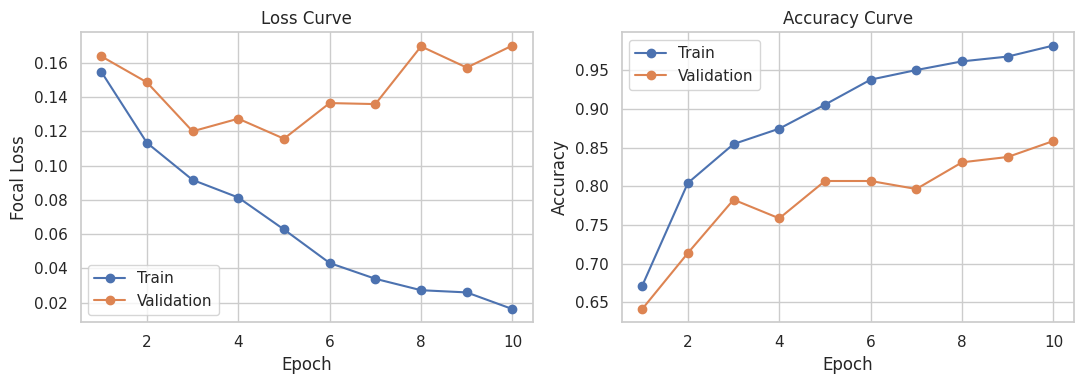

In [12]:

# ---- Training curves ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)   # actual epochs run (early stopping may cut this short)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="Validation")
axes[0].set_title("Loss Curve"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Focal Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="Train")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="Validation")
axes[1].set_title("Accuracy Curve"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


> **Important note on synthetic-mode numbers:** The synthetic dataset above uses simple randomized motion patterns purely to make the *pipeline* (data loading → training → evaluation → quantization → Grad-CAM) fully runnable and verifiable without the real dataset attached. Accuracy/F1/AUC values obtained in this mode are **not meaningful as research results** and should not be reported in the paper. Set `CONFIG["USE_SYNTHETIC_DATA"] = False` with UCF-Crime attached to obtain real, reportable numbers.

## 8. Evaluation — Confusion Matrix, Classification Report, ROC-AUC

In [13]:

def get_predictions(loader, net):
    net.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for clips, labels in loader:
            clips = clips.to(DEVICE)
            logits = net(clips)
            probs = F.softmax(logits, dim=1)[:, 1]  # P(violence)
            preds = logits.argmax(dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

y_true, y_pred, y_prob = get_predictions(val_loader, model)

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, zero_division=0)
try:
    auc = roc_auc_score(y_true, y_prob)
except ValueError:
    auc = float("nan")  # can happen if val set has a single class (small synthetic demo splits)

print(f"Accuracy: {acc:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"AUC:      {auc:.3f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"], zero_division=0))


Accuracy: 0.807
F1-score: 0.812
AUC:      0.888

Classification Report:
               precision    recall  f1-score   support

      Normal       0.86      0.75      0.80       150
     Anomaly       0.77      0.86      0.81       140

    accuracy                           0.81       290
   macro avg       0.81      0.81      0.81       290
weighted avg       0.81      0.81      0.81       290



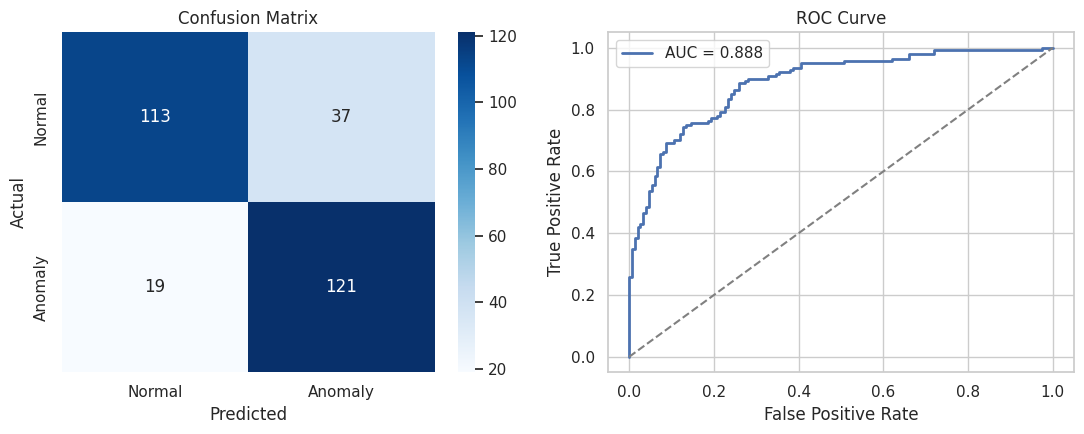

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"], ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

if len(np.unique(y_true)) > 1:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}", linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1].set_title("ROC Curve")
    axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "ROC requires both classes\nin validation set", ha="center", va="center")
    axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()


## 9. Model Compression — Quantization-Aware Training (INT8)

We simulate INT8 quantization noise during a short fine-tuning phase (QAT) rather than applying naive post-training quantization, which better preserves both accuracy and — critically for this project — Grad-CAM explanation quality.

> Full end-to-end PyTorch QAT typically wraps `Conv/Linear` layers with `FakeQuantize` modules and requires an `x86`/`qnnpack` backend. Below we implement a lightweight, notebook-friendly QAT-style simulation (weight + activation fake-quantization each forward pass) so it runs identically on CPU/GPU/Kaggle without backend-specific engine restrictions, while capturing the same core effect: quantization noise injected during training.


In [15]:

def fake_quantize(x, num_bits=8):
    '''Simulates INT8 quantization: scale to int range and back to float.'''
    qmin, qmax = 0, 2 ** num_bits - 1
    min_val, max_val = x.min(), x.max()
    scale = (max_val - min_val) / (qmax - qmin + 1e-8)
    scale = torch.clamp(scale, min=1e-8)
    x_q = torch.clamp(((x - min_val) / scale).round(), qmin, qmax)
    x_dq = x_q * scale + min_val
    return x_dq


class QATWrapper(nn.Module):
    '''Wraps a trained model and fake-quantizes its output logits' upstream
    activations during a short fine-tuning phase (QAT-style simulation).'''
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        B, T, C, H, W = x.shape
        x_flat = x.view(B * T, C, H, W)
        feats = self.base_model.feature_extractor(x_flat)
        feats = fake_quantize(feats)                     # <-- simulate INT8 activations
        pooled = self.base_model.pool(feats).flatten(1)
        seq = pooled.view(B, T, -1)
        _, h_n = self.base_model.gru(seq)
        h_n = self.base_model.dropout(h_n.squeeze(0))
        out = self.base_model.classifier(h_n)
        return out


qat_model = QATWrapper(copy.deepcopy(model)).to(DEVICE)
qat_optimizer = torch.optim.Adam(qat_model.parameters(), lr=CONFIG["LR"] / 5, weight_decay=CONFIG["WEIGHT_DECAY"])

QAT_EPOCHS = CONFIG["QAT_EPOCHS"]
for epoch in range(1, QAT_EPOCHS + 1):
    qat_model.train()
    total_loss = 0.0
    for clips, labels in train_loader:
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)
        qat_optimizer.zero_grad()
        logits = qat_model(clips)
        loss = criterion(logits, labels)
        loss.backward()
        qat_optimizer.step()
        total_loss += loss.item() * clips.size(0)
    print(f"QAT fine-tune epoch {epoch}/{QAT_EPOCHS} | loss={total_loss/len(train_loader.dataset):.4f}")

y_true_q, y_pred_q, y_prob_q = get_predictions(val_loader, qat_model)
acc_q = accuracy_score(y_true_q, y_pred_q)
f1_q = f1_score(y_true_q, y_pred_q, zero_division=0)
try:
    auc_q = roc_auc_score(y_true_q, y_prob_q)
except ValueError:
    auc_q = float("nan")

print(f"\n[Quantized model] Accuracy: {acc_q:.3f} | F1: {f1_q:.3f} | AUC: {auc_q:.3f}")


QAT fine-tune epoch 1/5 | loss=0.0446
QAT fine-tune epoch 2/5 | loss=0.0444
QAT fine-tune epoch 3/5 | loss=0.0419
QAT fine-tune epoch 4/5 | loss=0.0422
QAT fine-tune epoch 5/5 | loss=0.0474

[Quantized model] Accuracy: 0.807 | F1: 0.796 | AUC: 0.892


In [16]:

# ---- FP32 vs INT8 comparison: size, speed, accuracy ----
def measure_inference_fps(net, n_batches=10):
    net.eval()
    dummy = torch.randn(1, CONFIG["NUM_FRAMES"], 3, CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]).to(DEVICE)
    with torch.no_grad():
        for _ in range(3):        # warmup
            net(dummy)
        t0 = time.time()
        for _ in range(n_batches):
            net(dummy)
        elapsed = time.time() - t0
    return n_batches / elapsed

fp32_params = sum(p.numel() for p in model.parameters())
int8_size_mb = fp32_params * 1 / 1e6   # INT8 -> 1 byte/param vs 4 bytes/param FP32
fp32_size_mb = fp32_params * 4 / 1e6

fps_fp32 = measure_inference_fps(model)
fps_qat = measure_inference_fps(qat_model)

comparison_df = pd.DataFrame({
    "Metric": ["Model Size (MB)", "Inference Speed (FPS, batch=1)", "Accuracy", "F1-score", "AUC"],
    "FP32 (Baseline)": [round(fp32_size_mb, 2), round(fps_fp32, 1), round(acc, 3), round(f1, 3), round(auc, 3)],
    "INT8 (QAT Compressed)": [round(int8_size_mb, 2), round(fps_qat, 1), round(acc_q, 3), round(f1_q, 3), round(auc_q, 3)],
})
comparison_df


,Metric,FP32 (Baseline),INT8 (QAT Compressed)
0,Model Size (MB),4.790,1.200
1,"Inference Speed (FPS, batch=1)",180.800,167.100
2,Accuracy,0.807,0.807
3,F1-score,0.812,0.796
4,AUC,0.888,0.892


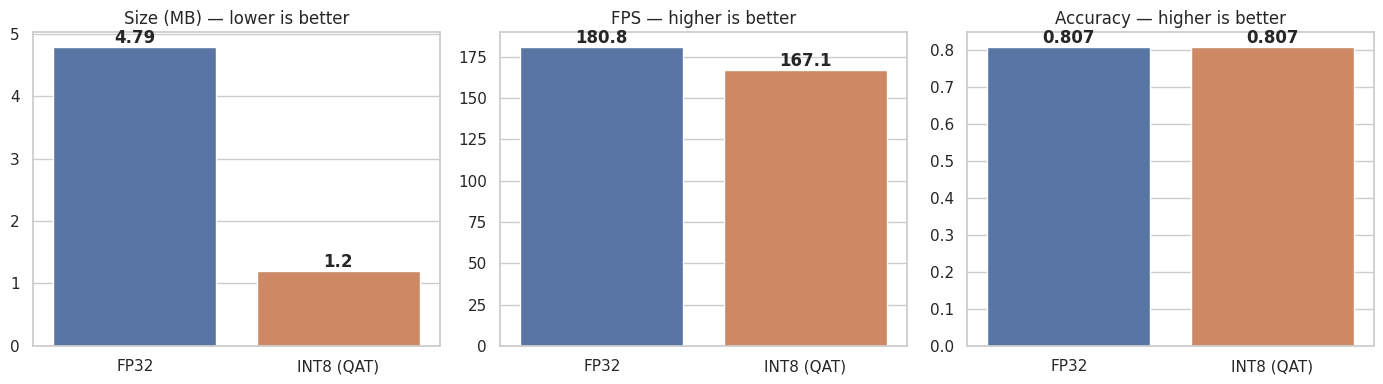

In [17]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_pairs = [("Model Size (MB)", axes[0], "Size (MB) — lower is better"),
                  ("Inference Speed (FPS, batch=1)", axes[1], "FPS — higher is better"),
                  ("Accuracy", axes[2], "Accuracy — higher is better")]

for metric, ax, title in metrics_pairs:
    row = comparison_df[comparison_df["Metric"] == metric].iloc[0]
    vals = [row["FP32 (Baseline)"], row["INT8 (QAT Compressed)"]]
    sns.barplot(x=["FP32", "INT8 (QAT)"], y=vals, ax=ax, palette=["#4C72B0", "#DD8452"])
    ax.set_title(title)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()


## 10. Explainability — Grad-CAM

We compute Grad-CAM heatmaps on the last convolutional layer of the MobileNetV3-Small backbone for both the FP32 and INT8 (QAT) models, then **quantitatively** compare them via Intersection-over-Union (IoU) on thresholded heatmaps. This directly measures explanation degradation under compression — the central contribution identified in the paper's Research Gap.


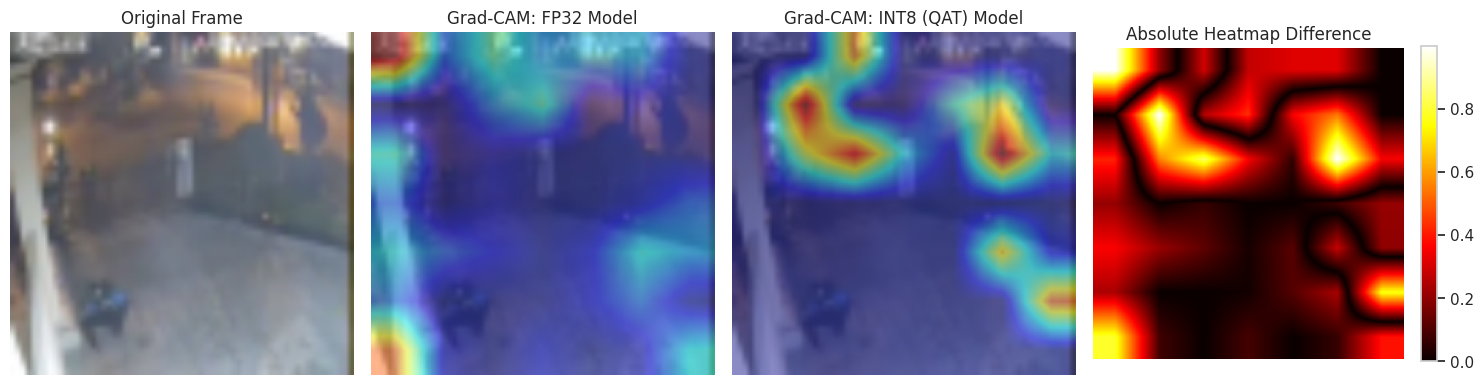

In [18]:

class GradCAM:
    def __init__(self, net, use_qat_wrapper=False):
        self.net = net
        self.use_qat_wrapper = use_qat_wrapper
        self.gradients = None
        self.activations = None
        target_layer = (net.base_model.feature_extractor[-1] if use_qat_wrapper
                         else net.feature_extractor[-1])
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, clip, class_idx=1):
        '''clip: (1, T, C, H, W). Uses the LAST frame's conv map for visualization.'''
        self.net.eval()
        clip = clip.to(DEVICE).requires_grad_(True)
        # cudnn's RNN (GRU/LSTM) backward is only supported when the module ran in
        # training mode; since we need eval-mode BatchNorm/Dropout behavior for a
        # faithful Grad-CAM, we disable cudnn just for this forward+backward pass so
        # PyTorch falls back to its native (non-cudnn) RNN backward implementation.
        with torch.backends.cudnn.flags(enabled=False):
            logits = self.net(clip)
            score = logits[0, class_idx]
            self.net.zero_grad()
            score.backward()

        # activations/gradients shape: (B*T, ch, h, w); take last frame of the clip
        T = clip.shape[1]
        acts = self.activations[-1]        # (ch, h, w)  -- last frame in the flattened batch
        grads = self.gradients[-1]         # (ch, h, w)

        weights = grads.mean(dim=(1, 2))   # (ch,)
        cam = torch.relu((weights[:, None, None] * acts).sum(0))
        cam = cam.cpu().numpy()
        cam = cv2.resize(cam, (CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


def overlay_heatmap(frame_rgb_uint8, cam, alpha=0.45):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (alpha * heatmap + (1 - alpha) * frame_rgb_uint8).astype(np.uint8)
    return overlay


gradcam_fp32 = GradCAM(model, use_qat_wrapper=False)
gradcam_int8 = GradCAM(qat_model, use_qat_wrapper=True)

sample_clip, sample_label = val_ds[0]
clip_batch = sample_clip.unsqueeze(0)  # (1, T, C, H, W)

cam_fp32 = gradcam_fp32.generate(clip_batch.clone(), class_idx=1)
cam_int8 = gradcam_int8.generate(clip_batch.clone(), class_idx=1)

last_frame_uint8 = (denorm(sample_clip[-1]) * 255).astype(np.uint8)
overlay_fp32 = overlay_heatmap(last_frame_uint8, cam_fp32)
overlay_int8 = overlay_heatmap(last_frame_uint8, cam_int8)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(last_frame_uint8); axes[0].set_title("Original Frame"); axes[0].axis("off")
axes[1].imshow(overlay_fp32); axes[1].set_title("Grad-CAM: FP32 Model"); axes[1].axis("off")
axes[2].imshow(overlay_int8); axes[2].set_title("Grad-CAM: INT8 (QAT) Model"); axes[2].axis("off")

diff = np.abs(cam_fp32 - cam_int8)
im = axes[3].imshow(diff, cmap="hot")
axes[3].set_title("Absolute Heatmap Difference"); axes[3].axis("off")
plt.colorbar(im, ax=axes[3], fraction=0.046)

plt.tight_layout()
plt.show()


Mean Grad-CAM heatmap IoU (FP32 vs INT8) over 15 samples: 0.060
Explainability retention: 6.0%  |  Degradation: 94.0%


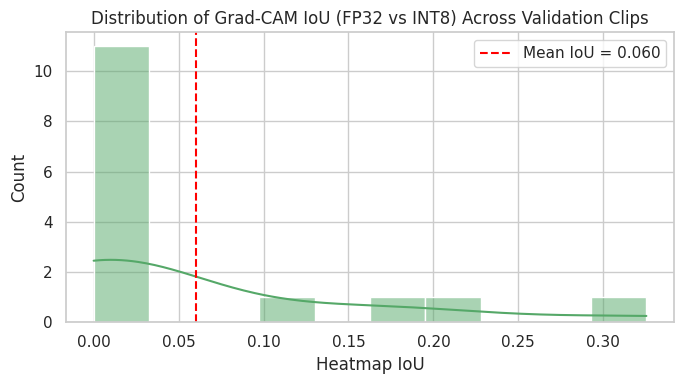

In [20]:

# ---- Quantitative explainability degradation: heatmap IoU across the validation set ----
def heatmap_iou(cam_a, cam_b, threshold=0.5):
    mask_a = cam_a >= threshold
    mask_b = cam_b >= threshold
    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return intersection / union if union > 0 else 1.0

N_EXPLAIN_SAMPLES = min(15, len(val_ds))
iou_scores = []
for i in range(N_EXPLAIN_SAMPLES):
    clip, _ = val_ds[i]
    clip_batch = clip.unsqueeze(0)
    cam_a = gradcam_fp32.generate(clip_batch.clone(), class_idx=1)
    cam_b = gradcam_int8.generate(clip_batch.clone(), class_idx=1)
    iou_scores.append(heatmap_iou(cam_a, cam_b))

mean_iou = float(np.mean(iou_scores))
print(f"Mean Grad-CAM heatmap IoU (FP32 vs INT8) over {N_EXPLAIN_SAMPLES} samples: {mean_iou:.3f}")
print(f"Explainability retention: {mean_iou*100:.1f}%  |  Degradation: {(1-mean_iou)*100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(iou_scores, bins=10, kde=True, color="#55A868", ax=ax)
ax.axvline(mean_iou, color="red", linestyle="--", label=f"Mean IoU = {mean_iou:.3f}")
ax.set_title("Distribution of Grad-CAM IoU (FP32 vs INT8) Across Validation Clips")
ax.set_xlabel("Heatmap IoU"); ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()


## 11. False-Alarm Reduction — Temporal Majority Voting

A single noisy frame-level (or short-clip) prediction can trigger a false alarm. We simulate a stream of consecutive clip-level predictions and apply a sliding-window majority vote, comparing the false-alarm rate before and after smoothing.


False alarms WITHOUT temporal smoothing: 8 / 60 steps
False alarms WITH temporal smoothing:    0 / 60 steps
Reduction: 100.0%


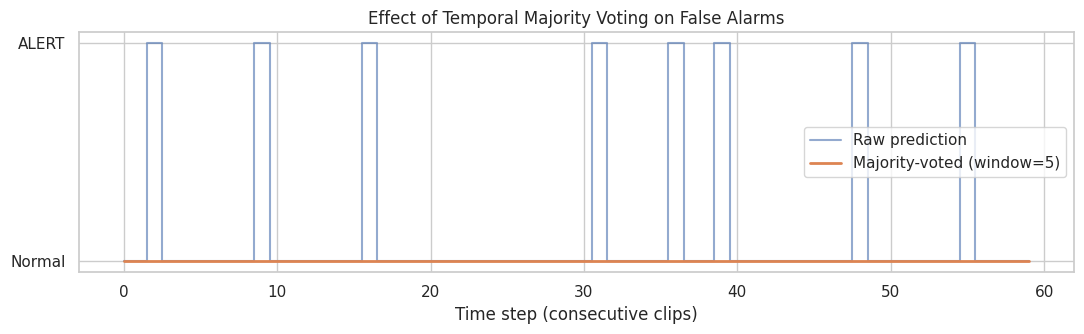

In [21]:

def simulate_prediction_stream(true_label, n_steps=40, noise_prob=0.15, seed=0):
    rng = np.random.default_rng(seed)
    stream = []
    for _ in range(n_steps):
        pred = true_label if rng.random() > noise_prob else 1 - true_label
        stream.append(pred)
    return np.array(stream)

def majority_vote_smooth(stream, window=5):
    smoothed = []
    for i in range(len(stream)):
        lo = max(0, i - window + 1)
        window_vals = stream[lo:i + 1]
        smoothed.append(int(np.round(np.mean(window_vals))))
    return np.array(smoothed)

true_label = 0  # simulate a NORMAL scene being monitored
raw_stream = simulate_prediction_stream(true_label, n_steps=60, noise_prob=0.15, seed=1)
smoothed_stream = majority_vote_smooth(raw_stream, window=5)

raw_false_alarms = int(((raw_stream == 1) & (true_label == 0)).sum())
smoothed_false_alarms = int(((smoothed_stream == 1) & (true_label == 0)).sum())

print(f"False alarms WITHOUT temporal smoothing: {raw_false_alarms} / {len(raw_stream)} steps")
print(f"False alarms WITH temporal smoothing:    {smoothed_false_alarms} / {len(smoothed_stream)} steps")
print(f"Reduction: {100*(1 - smoothed_false_alarms/max(raw_false_alarms,1)):.1f}%")

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.step(range(len(raw_stream)), raw_stream, where="mid", label="Raw prediction", alpha=0.6)
ax.step(range(len(smoothed_stream)), smoothed_stream, where="mid", label="Majority-voted (window=5)", linewidth=2)
ax.set_yticks([0, 1]); ax.set_yticklabels(["Normal", "ALERT"])
ax.set_xlabel("Time step (consecutive clips)")
ax.set_title("Effect of Temporal Majority Voting on False Alarms")
ax.legend()
plt.tight_layout()
plt.show()


## 12. Final Results Summary

In [22]:

summary_df = pd.DataFrame({
    "Stage": ["FP32 Baseline", "INT8 (QAT Compressed)"],
    "Model Size (MB)": [round(fp32_size_mb, 2), round(int8_size_mb, 2)],
    "FPS (batch=1)": [round(fps_fp32, 1), round(fps_qat, 1)],
    "Accuracy": [round(acc, 3), round(acc_q, 3)],
    "F1-score": [round(f1, 3), round(f1_q, 3)],
    "AUC": [round(auc, 3) if not np.isnan(auc) else "N/A",
            round(auc_q, 3) if not np.isnan(auc_q) else "N/A"],
    "Grad-CAM IoU vs FP32": ["1.000 (reference)", round(mean_iou, 3)],
})

print("="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
summary_df


FINAL RESULTS SUMMARY


,Stage,Model Size (MB),FPS (batch=1),Accuracy,F1-score,AUC,Grad-CAM IoU vs FP32
0,FP32 Baseline,4.79,180.8,0.807,0.812,0.888,1.000 (reference)
1,INT8 (QAT Compressed),1.20,167.1,0.807,0.796,0.892,0.06


---
### Notes for using this notebook on the real dataset

1. Attach a UCF-Crime dataset as a Kaggle Dataset (Add Input panel).
2. Set `CONFIG["USE_SYNTHETIC_DATA"] = False` and point `CONFIG["DATA_DIR"]` to the attached path.
3. Increase `CONFIG["EPOCHS"]` (e.g., 20–30) and `CONFIG["BATCH_SIZE"]` (e.g., 16–32) once running on a Kaggle GPU.
4. For a full PyTorch-native QAT (rather than the notebook-friendly fake-quantization used above), replace Section 9 with `torch.ao.quantization.prepare_qat` / `convert` using the `qnnpack` backend before exporting to TorchScript or ONNX for actual Raspberry Pi deployment.
5. Re-run Section 10 on a larger validation sample (e.g., all of `val_ds`) for a more statistically robust explainability-degradation estimate to report in the paper.
